# Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc

import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_blobs

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [5]:
# import warnings filter
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)

In [7]:
df = pd.read_csv('churn_preds.csv')

In [8]:
df.head()

,Actual,Predicted,Predicted_Proba_Class1
0,0.0,0.0,0.013995
1,0.0,0.0,0.013041
2,1.0,1.0,0.641389
3,0.0,0.0,0.221872
4,0.0,0.0,0.022161


# ROC Curve and AUC

ROC AUC of Model=0.88


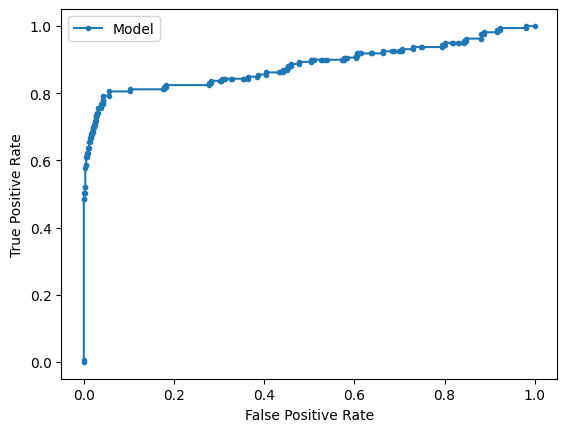

In [9]:
# keep probabilities for the positive outcome only
probs = df['Predicted_Proba_Class1']
# calculate ROC AUC score
roc_auc = roc_auc_score(df['Actual'], probs)
# summarize score
print('ROC AUC of Model=%.2f' % (roc_auc))
# calculate roc curves
fpr, tpr, _ = roc_curve(df['Actual'], probs)
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.', label='Model')
# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend()
# show the plot
plt.show()

# PRC Curve and AUC

PRC AUC of Model=0.82


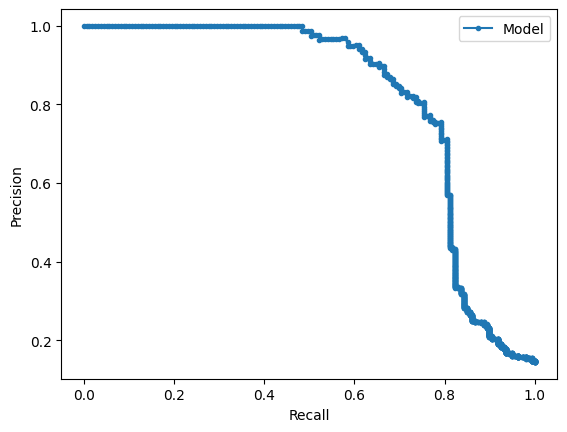

In [10]:
# keep probabilities for the positive outcome only
probs = df['Predicted_Proba_Class1']
precision, recall, _ = precision_recall_curve(df['Actual'], probs)
#f1 = f1_score(testy, yhat)
prc_auc  = auc(recall, precision)
# summarize scores
print('PRC AUC of Model=%.2f' % prc_auc)


plt.plot(recall, precision, marker='.', label='Model')
# axis labels
plt.xlabel('Recall')
plt.ylabel('Precision')
# show the legend
plt.legend()
# show the plot
plt.show()



# Generate a Classification Dataset using SKLearn

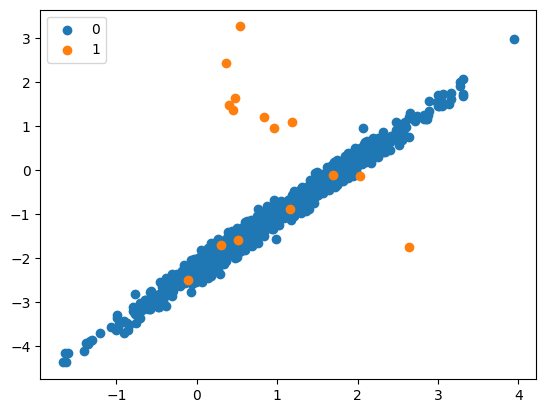

In [15]:
# generate dataset
#separable = False
#while not separable:
#    samples = make_classification(n_samples=1000, n_features=2, n_redundant=0, n_clusters_per_class=1,
#                               weights=[0.99])
#    class0 = samples[0][samples[1] == 0]
#    class1 = samples[0][samples[1] == 1]
#    separable = any([class0[:, k].max() < class1[:, k].min() or class0[:, k].min() > class1[:, k].max() for k in range(2)])

    
samples = make_classification(n_samples=1000, n_features=2, n_redundant=0, n_clusters_per_class=1,
                               weights=[0.99])
X = samples[0]
y = samples[1]

# scatter plot of examples by class label
for label in np.unique(y):
    row_ix = np.where(y == label)[0]
    plt.scatter(X[row_ix, 0], X[row_ix, 1], label=str(label))
plt.legend()
plt.show()

# Split Dataset into Train/Test Splits (Stratified Splits)

In [19]:
# split into train/test sets with same class ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y)


In [24]:
# calculate heuristic class weighting
from sklearn.utils.class_weight import compute_class_weight

# calculate class weighting according to training data
# Weight of class i = Total No of instances / (No of Classes * No of instances in class i)
weighting = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)

print(weighting)

weights = {0:weighting[0], 1:weighting[1]} 

[ 0.50744249 34.09090909]


# Train Decision Tree

In [27]:
# define model
model = DecisionTreeClassifier(class_weight=weights)
# fit model
model.fit(X_train, y_train)
# predict on test set
y_pred = model.predict(X_test)
# evaluate predictions
print('Accuracy: %.3f' % accuracy_score(y_test, y_pred))
print('Precision: %.3f' % precision_score(y_test, y_pred))
print('Recall: %.3f' % recall_score(y_test, y_pred))
print('F-measure: %.3f' % f1_score(y_test, y_pred))

Accuracy: 0.980
Precision: 0.400
Recall: 0.500
F-measure: 0.444


# Train Logistic Regression

In [29]:
# define model
model = LogisticRegression(solver='liblinear', class_weight=weights)
# fit model
model.fit(X_train, y_train)
# predict on test set
y_pred = model.predict(X_test)
# evaluate predictions
print('Accuracy: %.3f' % accuracy_score(y_test, y_pred))
print('Precision: %.3f' % precision_score(y_test, y_pred))
print('Recall: %.3f' % recall_score(y_test, y_pred))
print('F-measure: %.3f' % f1_score(y_test, y_pred))

Accuracy: 0.904
Precision: 0.083
Recall: 0.500
F-measure: 0.143
